<a href="https://colab.research.google.com/github/Clinton1029/Titanic_survived/blob/main/Titanic_survived.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Titanic Survival Prediction using Machine Learning

## Introduction
 The objective is to build a machine learning model that predicts whether a passenger survived the Titanic disaster based on information such as age, gender, passenger class, ticket fare, family size, and port of embarkation.

This is a **Supervised Machine Learning** problem because the dataset already contains the correct outcome (whether each passenger survived or not). The model learns patterns from the historical data and uses them to predict the survival of new passengers.

---

## Problem Statement

The RMS Titanic sank on **15 April 1912** after colliding with an iceberg during its maiden voyage. Out of the passengers and crew on board, only a portion survived. Historical records show that factors such as gender, age, passenger class, and family relationships influenced the chances of survival.

The goal of this project is to analyze the Titanic dataset, preprocess the data, build a machine learning model, and evaluate its ability to predict whether a passenger survived.

---



# Understanding the Titanic Dataset

The Titanic dataset contains information about passengers who travelled aboard the Titanic. Each **row** represents one passenger, while each **column** represents one characteristic (feature) describing that passenger.

## Dataset Columns

### **PassengerId**
A unique identification number assigned to each passenger. It is mainly used for identification and does not influence whether a passenger survived.

### **Survived**
The target variable indicating whether the passenger survived.

- **0** = Did Not Survive
- **1** = Survived

### **Pclass**
Represents the passenger's travel class.

- **1** = First Class
- **2** = Second Class
- **3** = Third Class

Passenger class is often associated with socioeconomic status.

### **Name**
The full name of the passenger. It may contain useful information such as titles (Mr., Mrs., Miss, Dr., etc.) that can be extracted during feature engineering.

### **Sex**
The gender of the passenger.

Possible values:
- Male
- Female

### **Age**
The passenger's age in years.

Some passengers have missing age values that will need to be handled during data preprocessing.

### **SibSp**
The number of siblings and spouses travelling with the passenger.

### **Parch**
The number of parents and children travelling with the passenger.

### **Ticket**
The ticket number assigned to the passenger.

### **Fare**
The amount of money paid for the ticket.

### **Cabin**
The cabin number assigned to the passenger.

Many passengers have missing cabin information.

### **Embarked**
The port where the passenger boarded the Titanic.

Possible values are:

- **C** = Cherbourg
- **Q** = Queenstown
- **S** = Southampton

---

# Features and Target Variable

## Features (Independent Variables)

These are the input variables used by the machine learning model to predict survival.

Examples include:

- Passenger Class
- Sex
- Age
- Fare
- Embarked
- SibSp
- Parch

## Target Variable (Dependent Variable)

The target variable is:

**Survived**

where:

- **0** = Did Not Survive
- **1** = Survived

---

# Type of Machine Learning

This project is a **Supervised Machine Learning** problem because the dataset already contains the correct output.

More specifically, it is a **Binary Classification** problem since the model predicts one of two possible classes:

- Survived
- Did Not Survive

---

# Project Workflow

The project will follow these steps:

1. Import Required Libraries
2. Load the Dataset
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing & preparation
5. Feature Selection
6. Choose the Model
7. Split the Dataset into Training and Testing Sets
8. Train the Machine Learning Model
9. Evaluate Model Performance
10. Predict Survival for New Passengers


# 1. Import Required Libraries

In [12]:
# Import the os library for interacting with the operating system
import os

# Import the pandas library for data manipulation and analysis
import pandas as pd

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load the Titanic Dataset


In [3]:
# Specify the path to the Titanic dataset
file_path = "/content/titanictrain.csv"

# Check if the dataset file exists
if os.path.exists(file_path):

    # Load the dataset into a DataFrame
    df = pd.read_csv(file_path)

    print("Dataset loaded successfully.")

else:
    print("Dataset file not found. Please check the file path.")

Dataset loaded successfully.


# 3. Exploratory Data Analysis

### 3.1. Display the rows (5)

In [4]:
# Display the first five rows of the dataset

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 3.1.2  Display the last rows

In [5]:
# Display the last five rows of the dataset

df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


### 3.1.3 Display the dimension

In [6]:
# Display the number of rows and columns

df.shape

(891, 12)

### 3.1.4  Display the columns

In [7]:
# Display all column names

df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

### 3.1.5  Display the data infomation

In [8]:
# Display information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### 3.1.6 Display the statistical descreption

In [9]:
# Generate descriptive statistics

df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### 3.1.7  Check the missing values

In [10]:
# Count missing values in each column

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


###### There are missing values in Age, Cabin and Embarked hence cleaning is required to increase the data quality

### 3.1.8 Check the duplicates

In [11]:
# Count the number of duplicate rows

df.duplicated().sum()

np.int64(0)

###### There are no duplicates

## 3.2  Survival Distribution

This bar chart displays the number of passengers who survived and those who did not survive.

It provides an overview of the target variable (**Survived**) and helps determine whether the dataset is balanced or imbalanced before building a machine learning model.

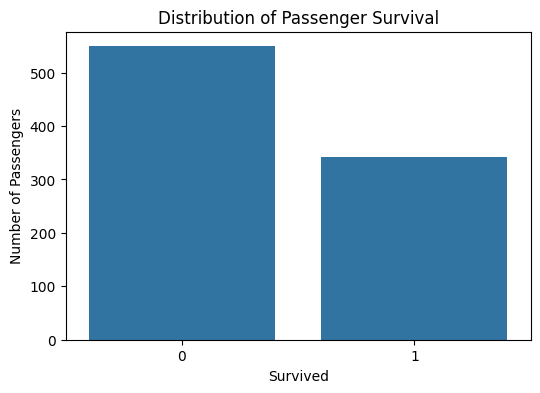

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(x="Survived", data=df)

plt.title("Distribution of Passenger Survival")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")

plt.show()

## 3.3 Survival by Gender

This visualization compares the survival outcomes of male and female passengers.

It helps determine whether gender influenced the likelihood of survival during the Titanic disaster.

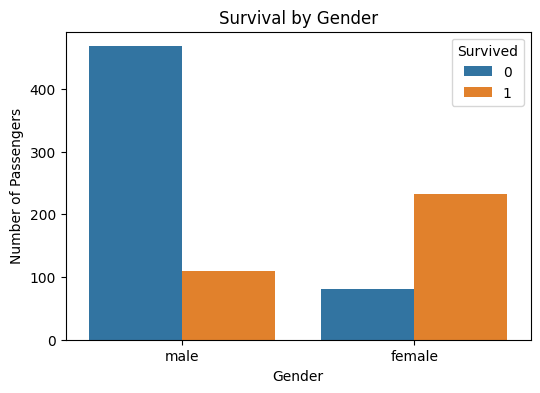

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(x="Sex", hue="Survived", data=df)

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

## 3.4 Survival by Passenger Class

This chart compares survival outcomes across the three passenger classes.

It helps determine whether travelling in a higher passenger class increased the chances of survival.

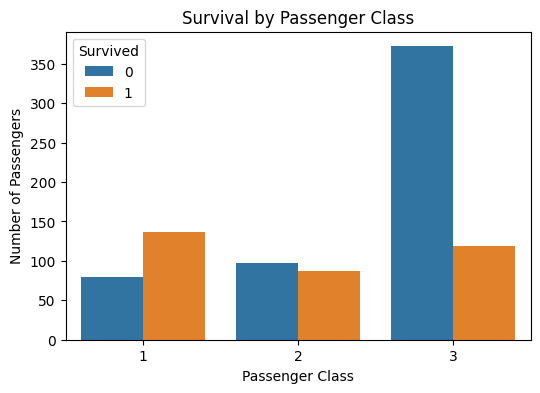

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(x="Pclass", hue="Survived", data=df)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

## 3.5 Age Distribution

This histogram illustrates the distribution of passenger ages.

It helps identify the most common age groups, the spread of the data, and whether the age variable is normally distributed or skewed.

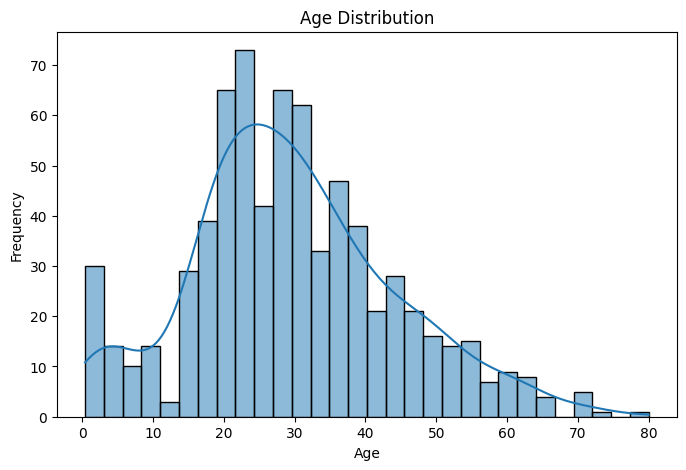

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

## 3.6 Correlation Heatmap

A correlation heatmap displays the strength and direction of relationships between numerical variables.

Correlation values range from:

- **1** = Strong positive relationship
- **0** = No relationship
- **-1** = Strong negative relationship

This visualization helps identify variables that may be useful for predicting passenger survival.

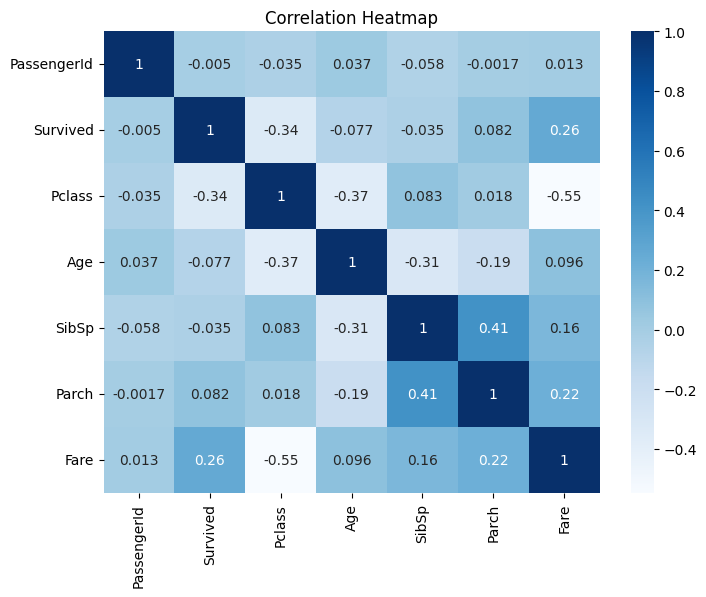

In [17]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")

plt.show()